# Step 14 — 3D-IRCADb-01 normalized conversion and parity QC

**Purpose:** convert the authorized Step 13 DICOM source into internal NIfTI volumes, prove source-to-normalized serialization parity, audit geometry and actual nonzero labels, and freeze a machine-readable conversion gate.

This notebook performs **no model inference**, opens **no local LiTS test data**, and does not compare against test statistics. Normalized derivatives are internal, non-redistributable research artifacts governed by the source CC BY-NC-ND 4.0 terms. Run All from this directory.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, platform, re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat, pydicom, nibabel as nib

STEP_DIR=Path.cwd().resolve()
assert STEP_DIR.name=="step_14_3d_ircadb_normalized_conversion_and_parity_qc", f"Run from Step 14 directory, got {STEP_DIR}"
PART2=STEP_DIR.parent
STEP13=PART2/"step_13_3d_ircadb_ingestion_and_qc"
STEP13_OUT=STEP13/"outputs"
SOURCE=STEP13_OUT/"extracted"
OUT=STEP_DIR/"outputs"; NORMALIZED=OUT/"normalized"
OUT.mkdir(exist_ok=True); NORMALIZED.mkdir(exist_ok=True)

EXPECTED_MANIFEST_SHA256="575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
EXPECTED_ARCHIVE_SET_SHA256="55cd6722da6c02f8365ab566603db116128e0d854782d2a174b85056f4a5ba96"
EXPECTED_PATIENTS=20
SOURCE_LICENSE="CC BY-NC-ND 4.0"
ALLOW_MODEL_INFERENCE=False
ALLOW_LOCAL_LITS_TEST_ACCESS=False
REDISTRIBUTION_AUTHORIZED=False

def sha256(path, chunk=1024*1024):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for b in iter(lambda:f.read(chunk),b""): h.update(b)
    return h.hexdigest()
def save_json(obj,name):
    (OUT/name).write_text(json.dumps(obj,indent=2,sort_keys=True,default=str),encoding="utf-8")
def save_csv(df,name):
    df.to_csv(OUT/name,index=False)
def patient_num(p): return int(p.name.split(".")[-1])

print("Step 14 directory:",STEP_DIR)
print("Source:",SOURCE)
print("Safety: inference=False, local LiTS test access=False")

Step 14 directory: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1 (part 2)\step_14_3d_ircadb_normalized_conversion_and_parity_qc
Source: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1 (part 2)\step_13_3d_ircadb_ingestion_and_qc\outputs\extracted
Safety: inference=False, local LiTS test access=False


## 1. Verify the signed Step 13 prerequisite

Fail closed if the Step 13 gate, archive set, manifest, patient count, or signed artifacts do not match. The source is read-only in this phase.


In [2]:
gate13=json.loads((STEP13_OUT/"gate_result.json").read_text(encoding="utf-8"))
sig13=json.loads((STEP13_OUT/"step_13_signature.json").read_text(encoding="utf-8"))
signed_checks=[]
for rel, expected in sig13["signed_artifacts"].items():
    p=PART2/rel
    signed_checks.append({"artifact":rel,"exists":p.is_file(),"expected_sha256":expected,
                          "actual_sha256":sha256(p) if p.is_file() else None,
                          "passed":p.is_file() and sha256(p)==expected})
signed_df=pd.DataFrame(signed_checks); save_csv(signed_df,"step_13_signature_verification.csv")
input_checks=pd.DataFrame([
 {"check":"step13_source_gate_pass","passed":gate13.get("source_ingestion_qc_passed") is True,"actual":gate13.get("result_level")},
 {"check":"manifest_hash_match","passed":gate13.get("manifest_sha256")==EXPECTED_MANIFEST_SHA256,"actual":gate13.get("manifest_sha256")},
 {"check":"archive_set_hash_match","passed":gate13.get("archive_set_sha256")==EXPECTED_ARCHIVE_SET_SHA256,"actual":gate13.get("archive_set_sha256")},
 {"check":"patient_count_20","passed":gate13.get("extracted_patient_count")==EXPECTED_PATIENTS,"actual":gate13.get("extracted_patient_count")},
 {"check":"all_step13_signed_artifacts_match","passed":bool(signed_df.passed.all()),"actual":int(signed_df.passed.sum())},
 {"check":"model_inference_disabled","passed":ALLOW_MODEL_INFERENCE is False,"actual":ALLOW_MODEL_INFERENCE},
 {"check":"local_lits_test_access_disabled","passed":ALLOW_LOCAL_LITS_TEST_ACCESS is False,"actual":ALLOW_LOCAL_LITS_TEST_ACCESS},
])
save_csv(input_checks,"input_verification.csv")
assert input_checks.passed.all(), input_checks.loc[~input_checks.passed].to_dict("records")
print("PASS: signed Step 13 source prerequisite verified")

PASS: signed Step 13 source prerequisite verified


## 2. Conversion helpers and frozen label semantics

- CT slices are sorted by spatial position projected onto the slice normal, with `InstanceNumber` only as fallback.
- DICOM pixels are transformed with `RescaleSlope` and `RescaleIntercept` and saved as float32 HU-like values.
- `liver` is the only liver label.
- Tumour is the union of folders matching `^livertumors?\d*$`; cyst, adrenal tumours, and generic non-liver tumour labels are excluded.
- NIfTI uses an LPS-to-RAS affine derived from DICOM orientation, pixel spacing, origin, and median slice spacing.


In [3]:
TUMOUR_PATTERN=re.compile(r"^livertumors?\d*$",re.I)
def deepest_named(root,name):
    c=[p for p in root.rglob(name) if p.is_dir() and any(x.is_file() for x in p.rglob("*"))]
    c=[p for p in c if not any(q!=p and p in q.parents for q in c)]
    assert len(c)==1,(root,name,[str(x) for x in c])
    return c[0]

def read_series(folder,pixels=True):
    rows=[]
    for p in folder.rglob("*"):
        if not p.is_file(): continue
        try:
            ds=pydicom.dcmread(p,force=True)
            if not hasattr(ds,"Rows"): continue
            ipp=np.asarray(getattr(ds,"ImagePositionPatient",[0,0,float(getattr(ds,"InstanceNumber",0))]),float)
            iop=np.asarray(getattr(ds,"ImageOrientationPatient",[1,0,0,0,1,0]),float)
            normal=np.cross(iop[:3],iop[3:]); position=float(np.dot(ipp,normal))
            rows.append((position,int(getattr(ds,"InstanceNumber",0)),p,ds))
        except Exception: continue
    assert rows,f"No readable DICOM in {folder}"
    rows.sort(key=lambda x:(x[0],x[1],x[2].name))
    if not pixels: return rows
    arrays=[]
    for _,_,_,ds in rows:
        a=ds.pixel_array
        slope=float(getattr(ds,"RescaleSlope",1)); intercept=float(getattr(ds,"RescaleIntercept",0))
        arrays.append(a.astype(np.float32)*slope+intercept)
    return rows,np.stack(arrays,axis=0)

def affine_from_ct(rows):
    first=rows[0][3]
    iop=np.asarray(getattr(first,"ImageOrientationPatient",[1,0,0,0,1,0]),float)
    row_dir=iop[:3]; col_dir=iop[3:]; normal=np.cross(row_dir,col_dir)
    ps=np.asarray(first.PixelSpacing,float); origin=np.asarray(first.ImagePositionPatient,float)
    positions=np.asarray([x[0] for x in rows],float)
    dz=float(np.median(np.abs(np.diff(positions)))) if len(positions)>1 else float(getattr(first,"SliceThickness",1))
    lps=np.eye(4); lps[:3,0]=row_dir*ps[1]; lps[:3,1]=col_dir*ps[0]; lps[:3,2]=normal*dz; lps[:3,3]=origin
    ras=np.diag([-1.,-1.,1.,1.])@lps
    return ras,dz,ps,iop,positions

def aligned_mask(label_dir,ct_rows):
    mrows,mstack=read_series(label_dir,pixels=True)
    index={int(inst):i for i,(_,inst,_,_) in enumerate(mrows)}
    out=np.zeros((len(ct_rows),int(ct_rows[0][3].Rows),int(ct_rows[0][3].Columns)),dtype=np.uint8)
    missing=[]; pos_err=[]
    for zi,(ctpos,inst,_,_) in enumerate(ct_rows):
        if inst not in index: missing.append(inst); continue
        mi=index[inst]; out[zi]=(mstack[mi]>0).astype(np.uint8); pos_err.append(abs(ctpos-mrows[mi][0]))
    return out,{"source_slices":len(mrows),"matched_slices":len(ct_rows)-len(missing),"missing_instances":len(missing),
                "max_position_error_mm":max(pos_err) if pos_err else np.nan}
print("Helpers ready")

Helpers ready


## 3. Convert all 20 cases and prove serialization parity

This is an internal format conversion only. Existing case outputs are overwritten deterministically on rerun; all source archives/extractions remain untouched.


In [4]:
conversion=[]; geometry=[]; label_rows=[]; containment=[]; hu_rows=[]
patient_roots=sorted([p for p in SOURCE.glob("3Dircadb1.*") if p.is_dir()],key=patient_num)
assert len(patient_roots)==EXPECTED_PATIENTS
for case_idx,root in enumerate(patient_roots,1):
    pid=root.name; internal_id=f"ircadb_{patient_num(root):02d}"; case_out=NORMALIZED/internal_id; case_out.mkdir(exist_ok=True)
    ct_dir=deepest_named(root,"PATIENT_DICOM"); mask_root=deepest_named(root,"MASKS_DICOM")
    ct_rows,ct_zyx=read_series(ct_dir,True); affine,dz,ps,iop,positions=affine_from_ct(ct_rows)
    ct_xyz=np.transpose(ct_zyx,(2,1,0)).astype(np.float32)
    labels=[p for p in mask_root.iterdir() if p.is_dir()]
    liver_dirs=[p for p in labels if p.name.lower()=="liver"]
    tumour_dirs=[p for p in labels if TUMOUR_PATTERN.fullmatch(p.name)]
    assert len(liver_dirs)==1,f"{pid}: expected one liver folder"
    liver_zyx,lmeta=aligned_mask(liver_dirs[0],ct_rows)
    tumour_zyx=np.zeros_like(liver_zyx); nonzero_tumour_folders=0
    for td in tumour_dirs:
        arr,meta=aligned_mask(td,ct_rows); vox=int(arr.sum()); nonzero_tumour_folders+=int(vox>0); tumour_zyx|=arr
        label_rows.append({"source_patient_id":pid,"internal_patient_id":internal_id,"label_name":td.name,
          "source_slices":meta["source_slices"],"matched_slices":meta["matched_slices"],"missing_instances":meta["missing_instances"],
          "max_position_error_mm":meta["max_position_error_mm"],"nonzero_voxels":vox,"nonzero":vox>0})
    liver_xyz=np.transpose(liver_zyx,(2,1,0)); tumour_xyz=np.transpose(tumour_zyx,(2,1,0))
    paths={"ct":case_out/"ct_hu.nii.gz","liver":case_out/"liver_mask.nii.gz","tumour":case_out/"tumour_mask.nii.gz"}
    nib.save(nib.Nifti1Image(ct_xyz,affine),paths["ct"])
    nib.save(nib.Nifti1Image(liver_xyz.astype(np.uint8),affine),paths["liver"])
    nib.save(nib.Nifti1Image(tumour_xyz.astype(np.uint8),affine),paths["tumour"])
    ct2=np.asanyarray(nib.load(paths["ct"]).dataobj); lv2=np.asanyarray(nib.load(paths["liver"]).dataobj); tm2=np.asanyarray(nib.load(paths["tumour"]).dataobj)
    outside=int(np.logical_and(tumour_zyx>0,liver_zyx==0).sum()); tv=int(tumour_zyx.sum()); lv=int(liver_zyx.sum())
    finite=bool(np.isfinite(ct2).all()); ct_equal=bool(np.array_equal(ct2,ct_xyz)); lv_equal=bool(np.array_equal(lv2,liver_xyz)); tm_equal=bool(np.array_equal(tm2,tumour_xyz))
    conversion.append({"source_patient_id":pid,"internal_patient_id":internal_id,"ct_relative_path":str(paths['ct'].relative_to(STEP_DIR)),
      "liver_relative_path":str(paths['liver'].relative_to(STEP_DIR)),"tumour_relative_path":str(paths['tumour'].relative_to(STEP_DIR)),
      "shape_xyz":"x".join(map(str,ct_xyz.shape)),"ct_source_voxels":int(ct_xyz.size),"ct_normalized_voxels":int(ct2.size),
      "ct_exact_parity":ct_equal,"liver_source_voxels":lv,"liver_normalized_voxels":int(lv2.sum()),"liver_exact_parity":lv_equal,
      "tumour_source_voxels":tv,"tumour_normalized_voxels":int(tm2.sum()),"tumour_exact_parity":tm_equal,"ct_finite":finite,
      "ct_sha256":sha256(paths['ct']),"liver_sha256":sha256(paths['liver']),"tumour_sha256":sha256(paths['tumour'])})
    geometry.append({"source_patient_id":pid,"internal_patient_id":internal_id,"slices_z":len(ct_rows),"rows_y":ct_zyx.shape[1],"columns_x":ct_zyx.shape[2],
      "spacing_x_mm":float(ps[1]),"spacing_y_mm":float(ps[0]),"spacing_z_mm":dz,"z_span_mm":float(positions.max()-positions.min()),
      "orientation":";".join(f"{x:.6g}" for x in iop),"monotonic_positions":bool(np.all(np.diff(positions)>0))})
    containment.append({"source_patient_id":pid,"internal_patient_id":internal_id,"liver_voxels":lv,"tumour_voxels":tv,
      "tumour_outside_liver_voxels":outside,"tumour_containment_fraction":1.0 if tv==0 else 1-outside/tv,
      "tumour_folder_count":len(tumour_dirs),"nonzero_tumour_folder_count":nonzero_tumour_folders,"tumour_union_nonzero":tv>0})
    liver_hu=ct_zyx[liver_zyx>0]; tumour_hu=ct_zyx[tumour_zyx>0]
    hu_rows.append({"source_patient_id":pid,"internal_patient_id":internal_id,"ct_min_hu":float(ct_zyx.min()),"ct_max_hu":float(ct_zyx.max()),
      "ct_median_hu":float(np.median(ct_zyx)),"liver_mean_hu":float(liver_hu.mean()) if liver_hu.size else np.nan,
      "tumour_mean_hu":float(tumour_hu.mean()) if tumour_hu.size else np.nan,"tumour_minus_liver_hu":float(tumour_hu.mean()-liver_hu.mean()) if tumour_hu.size and liver_hu.size else np.nan})
    print(f"[{case_idx:02d}/20] {pid}: {ct_xyz.shape}, liver={lv:,}, tumour={tv:,}, tumour folders={len(tumour_dirs)}/{nonzero_tumour_folders}")

conversion=pd.DataFrame(conversion); geometry=pd.DataFrame(geometry); label_profile=pd.DataFrame(label_rows); containment=pd.DataFrame(containment); hu_profile=pd.DataFrame(hu_rows)
save_csv(conversion,"conversion_manifest.csv"); save_csv(conversion,"source_to_normalized_parity.csv")
save_csv(geometry,"patient_geometry_profile.csv"); save_csv(label_profile,"label_pixel_profile.csv")
save_csv(containment,"tumour_folder_vs_nonzero_audit.csv"); save_csv(containment,"overlap_and_containment_qc.csv"); save_csv(hu_profile,"hu_profile.csv")
print("Converted",len(conversion),"patients")

[01/20] 3Dircadb1.1: (512, 512, 129), liver=2,865,131, tumour=214,268, tumour folders=7/7
[02/20] 3Dircadb1.2: (512, 512, 172), liver=1,648,024, tumour=14,062, tumour folders=1/1
[03/20] 3Dircadb1.3: (512, 512, 200), liver=2,375,079, tumour=14,252, tumour folders=1/1
[04/20] 3Dircadb1.4: (512, 512, 91), liver=1,132,427, tumour=6,736, tumour folders=1/1
[05/20] 3Dircadb1.5: (512, 512, 139), liver=2,124,505, tumour=0, tumour folders=0/0
[06/20] 3Dircadb1.6: (512, 512, 135), liver=1,828,493, tumour=434,721, tumour folders=1/1
[07/20] 3Dircadb1.7: (512, 512, 151), liver=1,461,944, tumour=0, tumour folders=0/0
[08/20] 3Dircadb1.8: (512, 512, 124), liver=3,215,090, tumour=20,318, tumour folders=3/3
[09/20] 3Dircadb1.9: (512, 512, 111), liver=1,265,420, tumour=39,484, tumour folders=1/1
[10/20] 3Dircadb1.10: (512, 512, 122), liver=1,871,804, tumour=14,981, tumour folders=1/1
[11/20] 3Dircadb1.11: (512, 512, 132), liver=1,692,716, tumour=0, tumour folders=0/0
[12/20] 3Dircadb1.12: (512, 512, 2

## 4. Dataset findings, visualization, and machine-readable gate

The official description says 75% of patients have hepatic tumours. Folder presence alone is not sufficient; the gate uses actual nonzero tumour pixels and reports the reconciliation explicitly.


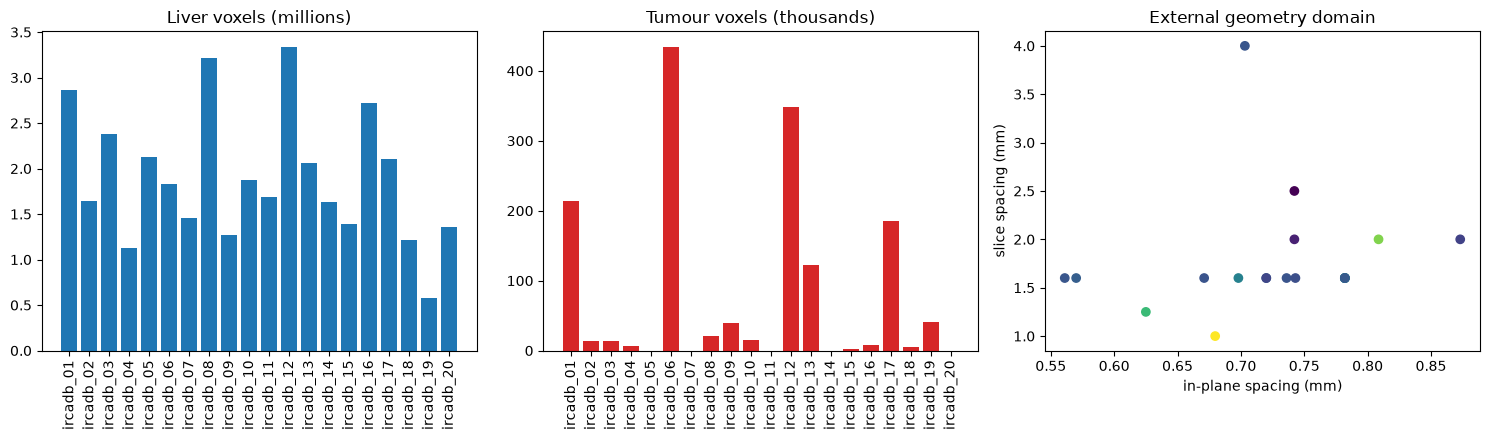

{
  "created_utc": "2026-08-05T14:21:59.993531+00:00",
  "result_level": "EXTERNAL_NORMALIZED_CONVERSION_QC_PASS",
  "conversion_qc_passed": true,
  "decision": "PROCEED_TO_FROZEN_EXTERNAL_EVALUATION_CONTRACT",
  "next_step": "step_15_frozen_external_evaluation_contract",
  "source": "3D-IRCADb-01",
  "license": "CC BY-NC-ND 4.0",
  "redistribution_authorized": false,
  "manifest_sha256": "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889",
  "archive_set_sha256": "55cd6722da6c02f8365ab566603db116128e0d854782d2a174b85056f4a5ba96",
  "converted_patient_count": 20,
  "tumour_folder_positive_cases": 15,
  "actual_nonzero_tumour_cases": 15,
  "tumour_folder_zero_union_cases": [],
  "minimum_tumour_containment_fraction": 0.9854482344302784,
  "model_inference_performed": false,
  "local_lits_test_accessed": false,
  "formal_external_evaluation_performed": false
}


In [5]:
actual_tumour_cases=int(containment.tumour_union_nonzero.sum())
folder_tumour_cases=int((containment.tumour_folder_count>0).sum())
zero_folder_cases=containment[(containment.tumour_folder_count>0)&(~containment.tumour_union_nonzero)]
min_containment=float(containment.loc[containment.tumour_union_nonzero,"tumour_containment_fraction"].min()) if actual_tumour_cases else np.nan

qc=pd.DataFrame([
 {"check":"signed_step13_prerequisite","required":True,"actual":bool(input_checks.passed.all()),"passed":bool(input_checks.passed.all())},
 {"check":"exactly_20_converted_patients","required":EXPECTED_PATIENTS,"actual":len(conversion),"passed":len(conversion)==EXPECTED_PATIENTS},
 {"check":"all_ct_finite","required":True,"actual":bool(conversion.ct_finite.all()),"passed":bool(conversion.ct_finite.all())},
 {"check":"all_ct_serialization_exact","required":True,"actual":bool(conversion.ct_exact_parity.all()),"passed":bool(conversion.ct_exact_parity.all())},
 {"check":"all_liver_serialization_exact","required":True,"actual":bool(conversion.liver_exact_parity.all()),"passed":bool(conversion.liver_exact_parity.all())},
 {"check":"all_tumour_serialization_exact","required":True,"actual":bool(conversion.tumour_exact_parity.all()),"passed":bool(conversion.tumour_exact_parity.all())},
 {"check":"all_mask_slices_matched","required":0,"actual":int(label_profile.missing_instances.sum()),"passed":int(label_profile.missing_instances.sum())==0},
 {"check":"all_mask_positions_match_ct","required":"<=0.001 mm","actual":float(label_profile.max_position_error_mm.max()),"passed":float(label_profile.max_position_error_mm.max())<=0.001},
 {"check":"all_liver_masks_nonempty","required":EXPECTED_PATIENTS,"actual":int((conversion.liver_source_voxels>0).sum()),"passed":bool((conversion.liver_source_voxels>0).all())},
 {"check":"official_tumour_case_count_reconciled","required":15,"actual":actual_tumour_cases,"passed":actual_tumour_cases==15},
 {"check":"zero_model_inference_runs","required":0,"actual":0,"passed":True},
 {"check":"zero_local_lits_test_accesses","required":0,"actual":0,"passed":True},
])
save_csv(qc,"conversion_qc_results.csv")
gate_pass=bool(qc.passed.all())
result_level="EXTERNAL_NORMALIZED_CONVERSION_QC_PASS" if gate_pass else "EXTERNAL_NORMALIZED_CONVERSION_QC_FAIL"
decision="PROCEED_TO_FROZEN_EXTERNAL_EVALUATION_CONTRACT" if gate_pass else "REPAIR_CONVERSION_OR_SOURCE_SEMANTICS"

fig,axes=plt.subplots(1,3,figsize=(15,4.5))
axes[0].bar(containment.internal_patient_id,containment.liver_voxels/1e6,label="liver"); axes[0].set_title("Liver voxels (millions)"); axes[0].tick_params(axis='x',rotation=90)
axes[1].bar(containment.internal_patient_id,containment.tumour_voxels/1e3,color="#d62728"); axes[1].set_title("Tumour voxels (thousands)"); axes[1].tick_params(axis='x',rotation=90)
axes[2].scatter(geometry.spacing_x_mm,geometry.spacing_z_mm,c=geometry.slices_z,cmap="viridis"); axes[2].set_xlabel("in-plane spacing (mm)"); axes[2].set_ylabel("slice spacing (mm)"); axes[2].set_title("External geometry domain")
fig.tight_layout(); fig.savefig(OUT/"conversion_qc_dashboard.png",dpi=160,bbox_inches="tight"); plt.show()

summary={"created_utc":datetime.now(timezone.utc).isoformat(),"result_level":result_level,"conversion_qc_passed":gate_pass,
 "decision":decision,"next_step":"step_15_frozen_external_evaluation_contract" if gate_pass else "repair_step_14",
 "source":"3D-IRCADb-01","license":SOURCE_LICENSE,"redistribution_authorized":False,
 "manifest_sha256":EXPECTED_MANIFEST_SHA256,"archive_set_sha256":EXPECTED_ARCHIVE_SET_SHA256,
 "converted_patient_count":len(conversion),"tumour_folder_positive_cases":folder_tumour_cases,"actual_nonzero_tumour_cases":actual_tumour_cases,
 "tumour_folder_zero_union_cases":zero_folder_cases.internal_patient_id.tolist(),"minimum_tumour_containment_fraction":min_containment,
 "model_inference_performed":False,"local_lits_test_accessed":False,"formal_external_evaluation_performed":False}
save_json(summary,"gate_result.json")
save_json({"phase":STEP_DIR.name,"created_utc":summary["created_utc"],"python":sys.version,"platform":platform.platform(),
 "pydicom":pydicom.__version__,"nibabel":nib.__version__,"numpy":np.__version__,"pandas":pd.__version__,
 "source_step13_signature_sha256":sha256(STEP13_OUT/"step_13_signature.json"),"source_read_only":True,
 "model_inference_allowed":False,"local_lits_test_access_allowed":False},"provenance.json")
save_json({"expected_patients":20,"tumour_definition":"union of nonzero ^livertumors?\\d*$ folders; excludes adrenal and generic non-liver tumour labels",
 "liver_definition":"exact folder liver","serialization_parity":"exact array equality after NIfTI reload",
 "source_license":SOURCE_LICENSE,"redistribution_authorized":False},"configuration.json")
print(json.dumps(summary,indent=2))
assert gate_pass, qc.loc[~qc.passed].to_dict("records")

## 5. Sign the result package

The signature covers tabular findings, gate, configuration, provenance, and dashboard. Large normalized NIfTI files are individually hashed in `conversion_manifest.csv` and therefore transitively covered by the signed manifest.


In [6]:
sign_names=["configuration.json","provenance.json","input_verification.csv","step_13_signature_verification.csv",
 "conversion_manifest.csv","source_to_normalized_parity.csv","patient_geometry_profile.csv","label_pixel_profile.csv",
 "tumour_folder_vs_nonzero_audit.csv","overlap_and_containment_qc.csv","hu_profile.csv","conversion_qc_results.csv",
 "conversion_qc_dashboard.png","gate_result.json"]
signed={str((OUT/n).relative_to(PART2)):sha256(OUT/n) for n in sign_names}
combined=hashlib.sha256("\n".join(f"{k}:{v}" for k,v in sorted(signed.items())).encode()).hexdigest()
save_json({"algorithm":"SHA-256","created_utc":datetime.now(timezone.utc).isoformat(),"combined_sha256":combined,
 "result_level":result_level,"signed_artifacts":signed,"normalized_artifact_hashes_are_in_conversion_manifest":True,
 "model_inference_performed":False,"local_lits_test_accessed":False},"step_14_signature.json")
print("Signed Step 14:",combined)

Signed Step 14: a023b54f4b93ca935162824b6e51d3e70a405383ae38ba5b89c675a24839dc90


## Interpretation

- A pass proves the external DICOM source was converted reproducibly and serialized without pixel loss.
- It does **not** prove model performance, external generalization, or formal model acceptance.
- The next step is to freeze the external evaluation cohort, preprocessing, model/checkpoint identity, metrics, failure handling, and one-time execution gate before any inference.
